# Radial Basis Function (RBF) Network Approximator

Radial Basis Function (RBF) networks are feedforward neural networks that evaluate distances from inputs to parameterized centroids. Using a Gaussian radial activation:
$$\phi(x) = \exp(-\gamma ||x - c_k||^2)$$
they approximate non-linear curves. This notebook implements a custom RBF network layer in PyTorch, trains it on a synthetic non-linear 1D sine wave, and visualizes the curve interpolation in Matplotlib.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Generate synthetic non-linear 1D curve data (400 samples)
np.random.seed(270)
n_samples = 400
X = np.random.uniform(-3, 3, (n_samples, 1))
# Target function is a highly non-linear curve
y = np.sin(X.ravel() * 1.5) * np.cos(X.ravel() * 0.5) + np.random.normal(0, 0.08, n_samples)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

print("Train inputs shape:", X_train_t.shape)
print("Test inputs shape: ", X_test_t.shape)



Train inputs shape: torch.Size([320, 1])
Test inputs shape:  torch.Size([80, 1])


## Custom RBF Layer & Network

We implement the RBF Layer:
- **Centroids**: 10 learnable centroids parameters ($c_k$).
- **Gamma**: Learnable variance parameter controlling Gaussian width.
- **Linear Layer**: Maps 10 RBF outputs to a single prediction.



In [2]:
class RBFNetwork(nn.Module):
    def __init__(self, in_dim=1, num_centroids=10):
        super(RBFNetwork, self).__init__()
        self.num_centroids = num_centroids
        
        # Learnable centroids coordinates initialized uniformly
        self.centroids = nn.Parameter(torch.randn(num_centroids, in_dim))
        # Learnable gamma scaling parameter
        self.gamma = nn.Parameter(torch.ones(num_centroids))
        # Final linear mapping layer
        self.linear = nn.Linear(num_centroids, 1)
        
    def forward(self, x):
        # Calculate pairwise squared distance matrix: shape [batch, num_centroids]
        batch_size = x.size(0)
        diff = x.unsqueeze(1) - self.centroids.unsqueeze(0) # [batch, centroids, dimensions]
        dist_sq = diff.pow(2).sum(dim=2) # [batch, centroids]
        
        # Gaussian activation
        rbf_out = torch.exp(-self.gamma.unsqueeze(0) * dist_sq)
        
        # Final linear approximation
        out = self.linear(rbf_out).squeeze(1)
        return out

model = RBFNetwork(in_dim=1, num_centroids=10)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.02)



## RBF Model Training

We optimize the RBF centroids and linear weights for 140 epochs.



In [3]:
epochs = 140
losses = []

for epoch in range(1, epochs + 1):
    model.train()
    predictions = model(X_train_t)
    loss = criterion(predictions, y_train_t)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 30 == 0:
        print(f"Epoch {epoch:3d}/{epochs} | MSE Training Loss: {loss.item():.4f}")

# Evaluate predictions on test split
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t).numpy()
    
r2 = r2_score(y_test, test_preds)
print(f"\nTest R² Score: {r2:.4f}")



Epoch  30/140 | MSE Training Loss: 0.0192
Epoch  60/140 | MSE Training Loss: 0.0070
Epoch  90/140 | MSE Training Loss: 0.0065
Epoch 120/140 | MSE Training Loss: 0.0065

Test R² Score: 0.9850


## RBF Curve Interpolation Plot

Using Matplotlib, we draw the actual test scatter points alongside the smooth RBF network interpolated curve prediction.



<cell>:23: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



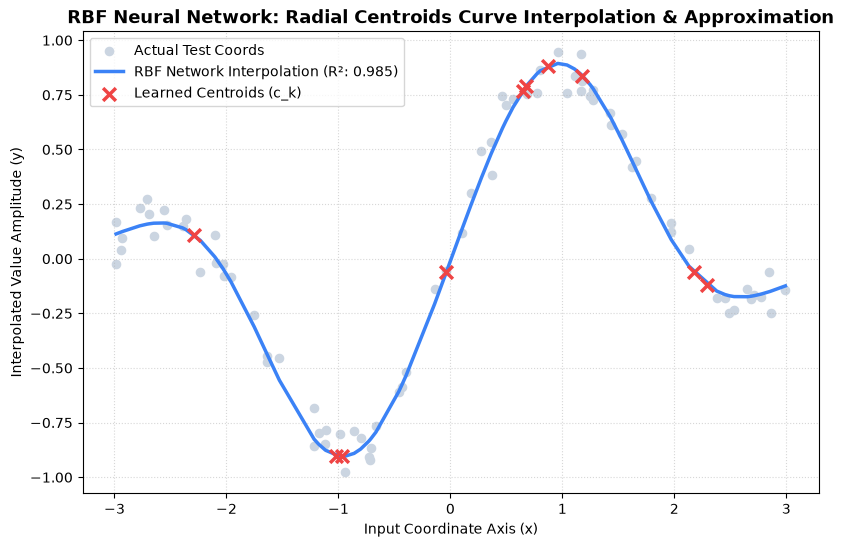

In [4]:
plt.figure(figsize=(9.5, 6))

# Sort test inputs for plotting a smooth curve line
sort_idx = np.argsort(X_test.ravel())
sorted_x = X_test.ravel()[sort_idx]
sorted_preds = test_preds[sort_idx]

plt.scatter(X_test, y_test, c='#CBD5E1', s=35, label='Actual Test Coords')
plt.plot(sorted_x, sorted_preds, color='#3B82F6', linewidth=2.5, label=f'RBF Network Interpolation (R²: {r2:.3f})')

# Scatter learned centroids locations on the curve
with torch.no_grad():
    learned_centroids = model.centroids.numpy()
    centroid_preds = model(model.centroids).numpy()
    
plt.scatter(learned_centroids, centroid_preds, c='#EF4444', marker='x', s=85, linewidths=2.5, zorder=5, label='Learned Centroids (c_k)')

plt.title('RBF Neural Network: Radial Centroids Curve Interpolation & Approximation', fontsize=13, fontweight='bold')
plt.xlabel('Input Coordinate Axis (x)')
plt.ylabel('Interpolated Value Amplitude (y)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()
